## Tasks 3–4: Methods 3 (Historical) & 5 (EWMA Hisorical)

---
## From Other Noteboks

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

DATA_RETURNS = 'data/returns_clean.csv'
DATA_PRICES  = 'data/prices_clean.csv'

STOCKS   = ['ASML', 'SHELL', 'JPM']
INDEX    = ['STOXX50', 'SP500']
RISKY    = STOCKS + INDEX

SAMPLE_START = '2017-01-01'
SAMPLE_END   = '2026-03-31'

PORTFOLIO_VALUE = 1_000_000
TRADING_DAYS    = 252
LOAN_MOD_DUR    = 9.135099

WEIGHTS = {
    'ASML':    0.178207,
    'SHELL':   0.040000,
    'JPM':     0.320000,
    'STOXX50': 0.040000,
    'SP500':   0.221793,
    'LOAN':    0.200000,
}

ASSETS = list(WEIGHTS.keys())
w      = np.array([WEIGHTS[c] for c in ASSETS])
ALPHAS = [0.99, 0.975]

## Methods 3 (Historical Simulation)

In [2]:
returns = pd.read_csv(DATA_RETURNS, index_col=0, parse_dates=True)
ret     = returns.loc[SAMPLE_START:SAMPLE_END, ASSETS].dropna()
n       = len(ret)
# portfolio loss
loss     = -PORTFOLIO_VALUE * (ret.values @ w)
# per asset losses
loss_mat = -PORTFOLIO_VALUE * (ret.values * w)

In [3]:
results_ind  = {}
results_port = {}

for alpha in ALPHAS:
    K    = int(np.ceil(n * alpha))
    frac = K - n * alpha

    ls    = np.sort(loss)
    var_p = ls[K - 1]
    es_p  = (ls[K:].sum() + frac * var_p) / (n * (1 - alpha))
    results_port[alpha] = {'VaR': var_p, 'ES': es_p}

    results_ind[alpha] = {}
    for i, col in enumerate(ASSETS):
        ls_i  = np.sort(loss_mat[:, i])
        var_i = ls_i[K - 1]
        es_i  = (ls_i[K:].sum() + frac * var_i) / (n * (1 - alpha))
        results_ind[alpha][col] = {'VaR': var_i, 'ES': es_i}

In [6]:
print(f"{'Asset':<12}  {'VaR 99%':>10}  {'ES 99%':>10}  {'VaR 97.5%':>10}  {'ES 97.5%':>10}")
print('-' * 58)
for col in ASSETS:
    v99, e99   = results_ind[0.99][col]['VaR'],   results_ind[0.99][col]['ES']
    v975, e975 = results_ind[0.975][col]['VaR'],  results_ind[0.975][col]['ES']
    print(f"{col:<12}  {v99:>10,.0f}  {e99:>10,.0f}  {v975:>10,.0f}  {e975:>10,.0f}")
print('-' * 58)
v99, e99   = results_port[0.99]['VaR'],   results_port[0.99]['ES']
v975, e975 = results_port[0.975]['VaR'],  results_port[0.975]['ES']
print(f"{'PORTFOLIO':<12}  {v99:>10,.0f}  {e99:>10,.0f}  {v975:>10,.0f}  {e975:>10,.0f}")

Asset            VaR 99%      ES 99%   VaR 97.5%    ES 97.5%
----------------------------------------------------------
ASML              10,568      14,607       7,955      11,152
SHELL              2,084       3,197       1,434       2,306
JPM               15,058      22,768      10,911      16,918
STOXX50            1,464       1,961         904       1,472
SP500              7,600      11,185       5,342       8,263
LOAN                 941       1,263         648         973
----------------------------------------------------------
PORTFOLIO         28,182      43,288      20,860      31,813


## Methods 5 (Filtered Historical Simulation)

In [7]:
lam   = 0.94
r_arr = ret[ASSETS].values
sigma   = np.zeros((n, len(ASSETS)))

for i in range(len(ASSETS)):
    sigma[0, i] = np.var(r_arr[:, i])
    for t in range(1, n):
        sigma[t, i] = lam * sigma[t-1, i] + (1 - lam) * r_arr[t-1, i] ** 2

sigma = np.sqrt(sigma)

In [8]:
z        = r_arr / sigma
sigma_next = np.sqrt(lam * sigma[-1] ** 2 + (1 - lam) * r_arr[-1] ** 2)
r_sim    = z * sigma_next

In [9]:
loss_sim     = -PORTFOLIO_VALUE * (r_sim @ w)
loss_sim_ind = -PORTFOLIO_VALUE * (r_sim * w)

In [10]:
f_results_ind  = {}
f_results_port = {}

for alpha in ALPHAS:
    K    = int(np.ceil(n * alpha))
    frac = K - n * alpha

    ls    = np.sort(loss_sim)
    var_p = ls[K - 1]
    es_p  = (ls[K:].sum() + frac * var_p) / (n * (1 - alpha))
    f_results_port[alpha] = {'VaR': var_p, 'ES': es_p}

    f_results_ind[alpha] = {}
    for i, col in enumerate(ASSETS):
        ls_i  = np.sort(loss_sim_ind[:, i])
        var_i = ls_i[K - 1]
        es_i  = (ls_i[K:].sum() + frac * var_i) / (n * (1 - alpha))
        f_results_ind[alpha][col] = {'VaR': var_i, 'ES': es_i}

In [11]:
print(f"{'Asset':<12}  {'VaR 99%':>10}  {'ES 99%':>10}  {'VaR 97.5%':>10}  {'ES 97.5%':>10}")
print('-' * 58)
for col in ASSETS:
    v99, e99   = f_results_ind[0.99][col]['VaR'],   f_results_ind[0.99][col]['ES']
    v975, e975 = f_results_ind[0.975][col]['VaR'],  f_results_ind[0.975][col]['ES']
    print(f"{col:<12}  {v99:>10,.0f}  {e99:>10,.0f}  {v975:>10,.0f}  {e975:>10,.0f}")
print('-' * 58)
v99, e99   = f_results_port[0.99]['VaR'],   f_results_port[0.99]['ES']
v975, e975 = f_results_port[0.975]['VaR'],  f_results_port[0.975]['ES']
print(f"{'PORTFOLIO':<12}  {v99:>10,.0f}  {e99:>10,.0f}  {v975:>10,.0f}  {e975:>10,.0f}")

Asset            VaR 99%      ES 99%   VaR 97.5%    ES 97.5%
----------------------------------------------------------
ASML              13,091      18,193       9,462      13,971
SHELL              2,004       2,653       1,473       2,083
JPM               13,451      17,919      10,338      14,252
STOXX50            1,570       2,091       1,214       1,653
SP500              6,923       9,374       4,892       7,264
LOAN                 975       1,362         733       1,031
----------------------------------------------------------
PORTFOLIO         29,072      35,620      20,877      28,944


## Backtesting

In [13]:
alpha_bt = 0.99
min_obs = 250

results_var  = {a: np.full(n, np.nan) for a in ALPHAS}
results_es   = {a: np.full(n, np.nan) for a in ALPHAS}
fresults_var = {a: np.full(n, np.nan) for a in ALPHAS}
fresults_es  = {a: np.full(n, np.nan) for a in ALPHAS}

for t in range(min_obs - 1, n - 1):
    sig_t   = sigma[t + 1]
    r_sim_t = z[:t + 1] * sig_t
    ls_fhs  = np.sort(-PORTFOLIO_VALUE * (r_sim_t @ w))
    ls_hs   = np.sort(loss[:t + 1])
    m       = t + 1

    for a in ALPHAS:
        K    = int(np.ceil(m * a))
        frac = K - m * a

        results_var[a][t + 1]  = ls_hs[K - 1]
        results_es[a][t + 1]   = (ls_hs[K:].sum()  + frac * ls_hs[K - 1])  / (m * (1 - a))
        fresults_var[a][t + 1] = ls_fhs[K - 1]
        fresults_es[a][t + 1]  = (ls_fhs[K:].sum() + frac * ls_fhs[K - 1]) / (m * (1 - a))

bt      = np.arange(min_obs, n)
bt_loss = loss[bt]
bt_dates = ret.index[bt]
m_bt    = len(bt)

### VaR violations + binomial test

In [15]:
print(f"{'Method':<12}  {'Alpha':>6}  {'Expected':>9}  {'Actual':>9}  {'Z':>8}  {'p':>7}")
print("-" * 62)
for label, vd in [("HS", results_var), ("FHS-EWMA", fresults_var)]:
    for a in ALPHAS:
        I    = (bt_loss > vd[a][bt]).astype(int)
        M    = I.sum()
        exp  = m_bt * (1 - a)
        Z    = (M - exp) / np.sqrt(m_bt * a * (1 - a))
        p    = 2 * (1 - stats.norm.cdf(abs(Z)))
        print(f"{label:<12}  {a*100:>5.1f}%  {exp:>9.1f}  {M:>9d}  {Z:>8.3f}  {p:>7.4f}")

Method         Alpha   Expected     Actual         Z        p
--------------------------------------------------------------
HS             99.0%       21.2         28     1.494   0.1351
HS             97.5%       52.9         65     1.685   0.0920
FHS-EWMA       99.0%       21.2         16    -1.127   0.2596
FHS-EWMA       97.5%       52.9         50    -0.404   0.6864


### ES violation residuals t-test

In [18]:
print(f"{'Method':<12}  {'Alpha':>6}  {'N viol':>7}  {'Mean K':>9}  {'t':>8}  {'p':>7}")
print("-" * 58)
for label, vd, ed in [("HS", results_var, results_es), ("FHS-EWMA", fresults_var, fresults_es)]:
    for a in ALPHAS:
        I  = bt_loss > vd[a][bt]
        K  = np.where(I, (bt_loss - ed[a][bt]) / ed[a][bt], 0.0)
        Kv = K[I]
        t_s, p = stats.ttest_1samp(Kv, 0)
        print(f"{label:<12}  {a*100:>5.1f}%  {len(Kv):>7}  {Kv.mean():>9.4f}  {t_s:>8.3f}  {p:>7.4f}")

Method         Alpha   N viol     Mean K         t        p
----------------------------------------------------------
HS             99.0%       28     0.1437     1.543   0.1345
HS             97.5%       65     0.0870     1.286   0.2030
FHS-EWMA       99.0%       16     0.0218     0.477   0.6403
FHS-EWMA       97.5%       50    -0.0147    -0.430   0.6690


### Elicitability VaR score

In [20]:
print(f"{'Method':<12}  {'Alpha':>6}  {'Score':>14}")
print("-" * 36)
for label, vd in [("HS", results_var), ("FHS-EWMA", fresults_var)]:
    for a in ALPHAS:
        vt    = vd[a][bt]
        score = np.sum(np.abs((bt_loss <= vt).astype(float) - a) * np.abs(bt_loss - vt))
        print(f"{label:<12}  {a*100:>5.1f}%  {score:>14,.0f}")

Method         Alpha           Score
------------------------------------
HS             99.0%       1,008,274
HS             97.5%       1,838,462
FHS-EWMA       99.0%         781,351
FHS-EWMA       97.5%       1,585,506


### Violations plot

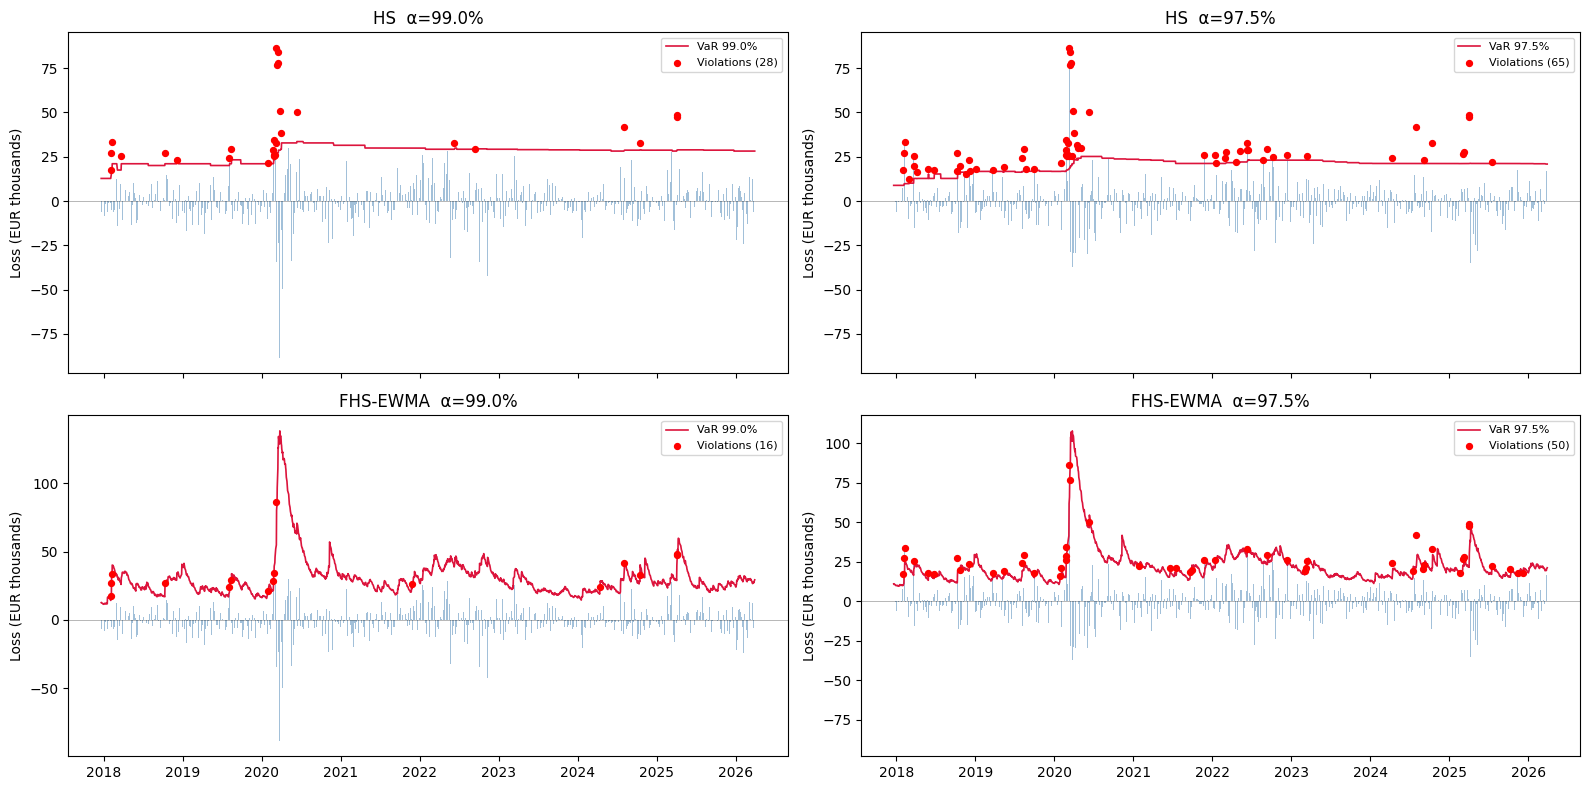

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
for row, (label, vd) in enumerate([("HS", results_var), ("FHS-EWMA", fresults_var)]):
    for col, a in enumerate(ALPHAS):
        ax = axes[row, col]
        vt = vd[a][bt]
        I  = bt_loss > vt
        ax.bar(bt_dates, bt_loss / 1e3, color="steelblue", alpha=0.5, width=1)
        ax.plot(bt_dates, vt / 1e3, color="crimson", lw=1.2, label=f"VaR {a*100:.1f}%")
        ax.scatter(bt_dates[I], bt_loss[I] / 1e3, color="red", s=18, zorder=5,
                   label=f"Violations ({I.sum()})")
        ax.axhline(0, color="black", lw=0.5, alpha=0.4)
        ax.set_title(f"{label}  α={a*100:.1f}%")
        ax.set_ylabel("Loss (EUR thousands)")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("plots/backtest_violations.png", dpi=150)
plt.show()

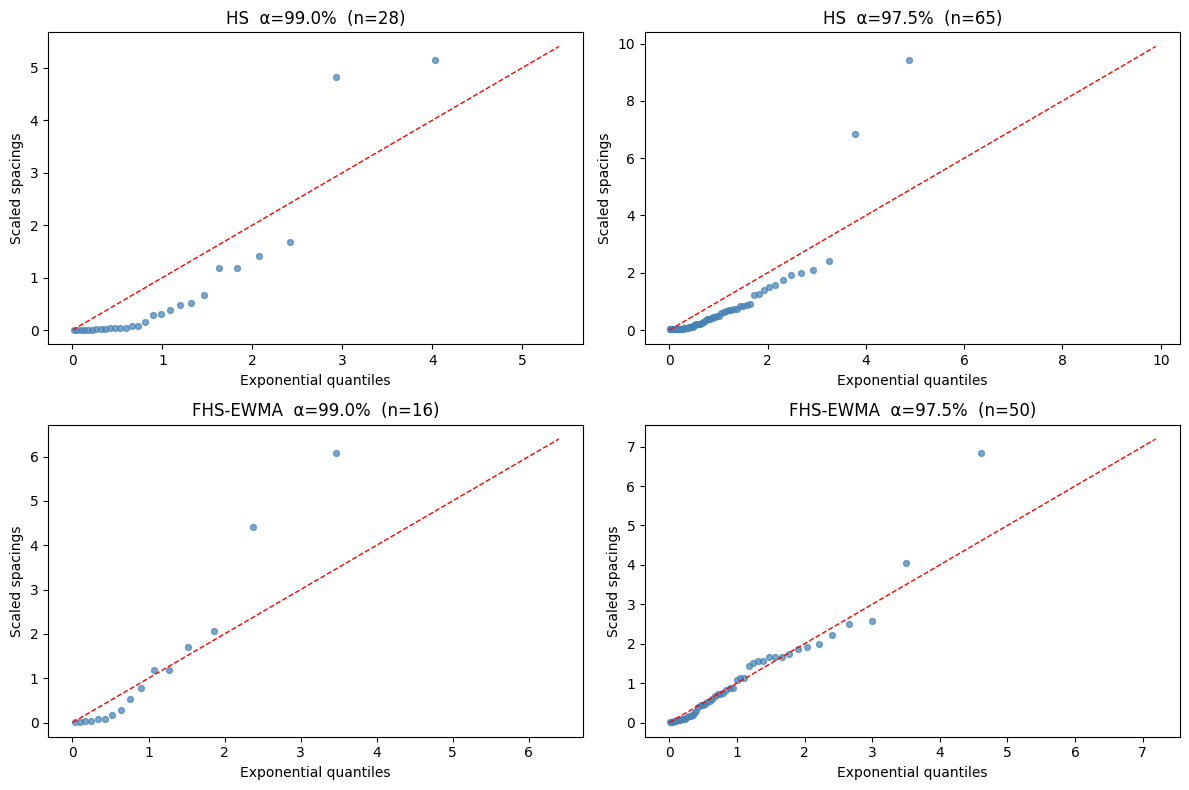

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (label, vd) in enumerate([("HS", results_var), ("FHS-EWMA", fresults_var)]):
    for col, a in enumerate(ALPHAS):
        ax      = axes[row, col]
        I       = bt_loss > vd[a][bt]
        vdays   = np.where(I)[0]
        spacing = np.diff(np.concatenate([[0], vdays])) * (1 - a)
        s_sort  = np.sort(spacing)
        probs   = (np.arange(1, len(s_sort) + 1) - 0.5) / len(s_sort)
        exp_q   = -np.log(1 - probs)
        ax.scatter(exp_q, s_sort, s=18, alpha=0.7, color="steelblue")
        lim = max(exp_q.max(), s_sort.max()) * 1.05
        ax.plot([0, lim], [0, lim], "r--", lw=1)
        ax.set_xlabel("Exponential quantiles")
        ax.set_ylabel("Scaled spacings")
        ax.set_title(f"{label}  α={a*100:.1f}%  (n={len(spacing)})")
plt.tight_layout()
plt.savefig("plots/backtest_qqplot.png", dpi=150)
plt.show()